# Denoising Autoencoder on MNIST

## Project Objective
Build a deep learning model that removes noise from handwritten digit images. A noisy image is given as input and the autoencoder learns to reconstruct the original clean image.

## Importing Required Packages

In [1]:
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split

## Setting Configuration

In [2]:
DATA_DIR = Path("mnist_png/testing")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001
NOISE_FACTOR = 0.30
VALIDATION_SPLIT = 0.2
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Loading MNIST PNG Dataset

In [3]:
class MnistPngDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)
        self.image_paths = sorted(self.root_dir.glob("*/*.png"))
        if not self.image_paths:
            raise FileNotFoundError(f"No PNG images found under {self.root_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        label = int(image_path.parent.name)
        image = Image.open(image_path).convert("L").resize((28, 28))
        image = np.asarray(image, dtype=np.float32) / 255.0
        image = torch.from_numpy(image).unsqueeze(0)
        return image, label

dataset = MnistPngDataset(DATA_DIR)
print("Total images:", len(dataset))
print("Classes:", sorted({path.parent.name for path in dataset.image_paths}))

Total images: 4660
Classes: ['0', '1', '2', '3', '4']


## Splitting Data and Creating Dataloaders

In [4]:
validation_size = int(len(dataset) * VALIDATION_SPLIT)
train_size = len(dataset) - validation_size

generator = torch.Generator().manual_seed(SEED)
train_dataset, validation_dataset = random_split(
    dataset,
    [train_size, validation_size],
    generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Training images:", len(train_dataset))
print("Validation images:", len(validation_dataset))

Training images: 3728
Validation images: 932


## Adding Noise to Images

In [5]:
def add_noise(images, noise_factor=NOISE_FACTOR):
    noise = noise_factor * torch.randn_like(images)
    noisy_images = images + noise
    return torch.clamp(noisy_images, 0.0, 1.0)

## Visualizing Clean and Noisy Images

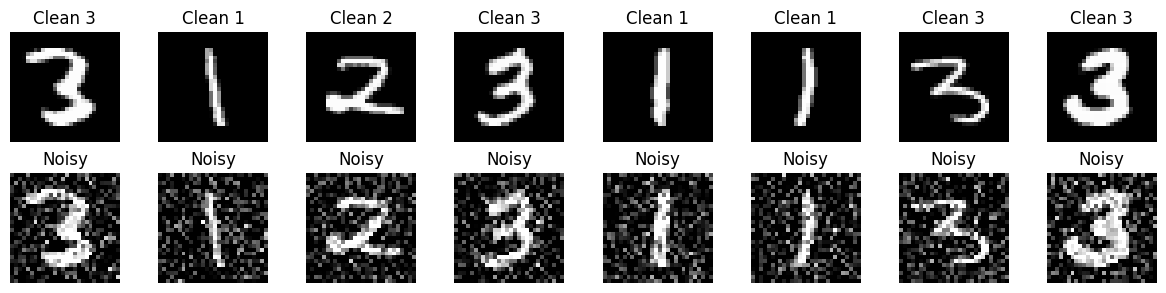

In [6]:
images, labels = next(iter(train_loader))
noisy_images = add_noise(images)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(images[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title(f"Clean {labels[i].item()}")

    axes[1, i].imshow(noisy_images[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("Noisy")

plt.tight_layout()
plt.show()

## Defining the Denoising Autoencoder Architecture

In [7]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = DenoisingAutoencoder().to(device)
print(model)

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU()
    (3): Upsample(scale_factor=2.0, mode='nearest')
    (4): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)


## Defining Loss Function and Optimizer

In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Helper Function for PSNR

In [9]:
def calculate_psnr(mse):
    if mse <= 0:
        return float("inf")
    return 20 * math.log10(1.0 / math.sqrt(mse))

## Training and Validation Phase

In [10]:
history = {"train_loss": [], "validation_loss": [], "validation_psnr": []}
best_validation_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0

    for clean_images, _ in train_loader:
        clean_images = clean_images.to(device)
        noisy_images = add_noise(clean_images)

        optimizer.zero_grad()
        denoised_images = model(noisy_images)
        loss = criterion(denoised_images, clean_images)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * clean_images.size(0)

    train_loss = train_loss / len(train_loader.dataset)

    model.eval()
    validation_loss = 0.0
    with torch.no_grad():
        for clean_images, _ in validation_loader:
            clean_images = clean_images.to(device)
            noisy_images = add_noise(clean_images)
            denoised_images = model(noisy_images)
            loss = criterion(denoised_images, clean_images)
            validation_loss += loss.item() * clean_images.size(0)

    validation_loss = validation_loss / len(validation_loader.dataset)
    validation_psnr = calculate_psnr(validation_loss)

    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)
    history["validation_psnr"].append(validation_psnr)

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        torch.save(model.state_dict(), OUTPUT_DIR / "best_denoising_autoencoder.pth")

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.5f} | "
        f"Validation Loss: {validation_loss:.5f} | "
        f"Validation PSNR: {validation_psnr:.2f} dB"
    )

Epoch 01/10 | Train Loss: 0.14916 | Validation Loss: 0.11496 | Validation PSNR: 9.39 dB
Epoch 02/10 | Train Loss: 0.11387 | Validation Loss: 0.11450 | Validation PSNR: 9.41 dB
Epoch 03/10 | Train Loss: 0.11375 | Validation Loss: 0.11448 | Validation PSNR: 9.41 dB
Epoch 04/10 | Train Loss: 0.11373 | Validation Loss: 0.11447 | Validation PSNR: 9.41 dB
Epoch 05/10 | Train Loss: 0.11372 | Validation Loss: 0.11446 | Validation PSNR: 9.41 dB
Epoch 06/10 | Train Loss: 0.11372 | Validation Loss: 0.11445 | Validation PSNR: 9.41 dB
Epoch 07/10 | Train Loss: 0.11371 | Validation Loss: 0.11445 | Validation PSNR: 9.41 dB
Epoch 08/10 | Train Loss: 0.11371 | Validation Loss: 0.11444 | Validation PSNR: 9.41 dB
Epoch 09/10 | Train Loss: 0.11370 | Validation Loss: 0.11444 | Validation PSNR: 9.41 dB
Epoch 10/10 | Train Loss: 0.11370 | Validation Loss: 0.11444 | Validation PSNR: 9.41 dB


## Plotting Training and Validation Loss

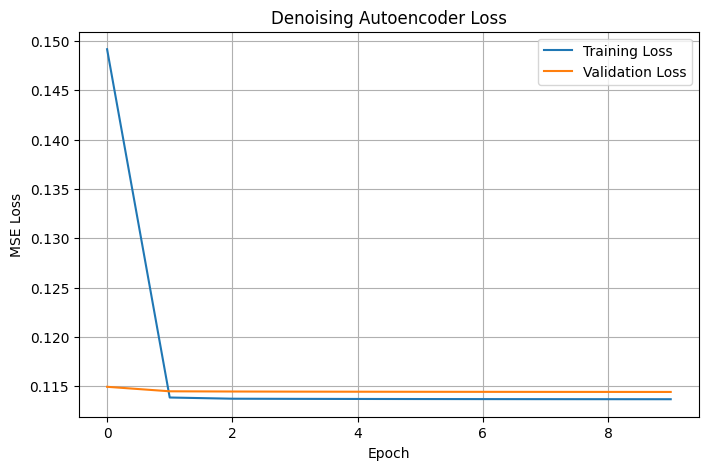

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Training Loss")
plt.plot(history["validation_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Denoising Autoencoder Loss")
plt.legend()
plt.grid(True)
plt.show()

## Testing the Denoising Result

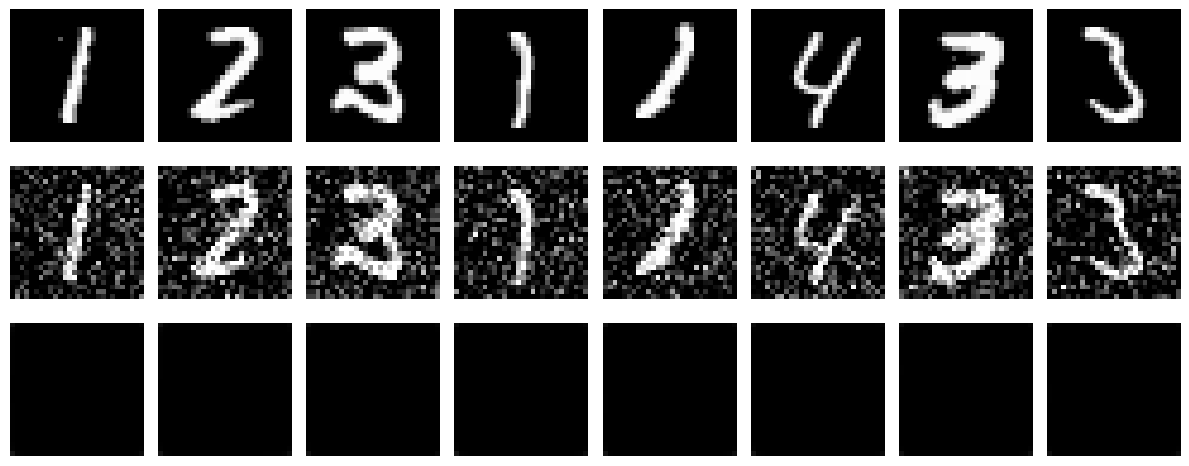

In [12]:
model.load_state_dict(torch.load(OUTPUT_DIR / "best_denoising_autoencoder.pth", map_location=device))
model.eval()

clean_images, labels = next(iter(validation_loader))
clean_images = clean_images[:8].to(device)
noisy_images = add_noise(clean_images)

with torch.no_grad():
    denoised_images = model(noisy_images)

clean_images = clean_images.cpu()
noisy_images = noisy_images.cpu()
denoised_images = denoised_images.cpu()

fig, axes = plt.subplots(3, 8, figsize=(12, 5))
row_names = ["Clean", "Noisy", "Denoised"]
image_rows = [clean_images, noisy_images, denoised_images]

for row_index, (row_name, row_images) in enumerate(zip(row_names, image_rows)):
    for col_index in range(8):
        axes[row_index, col_index].imshow(row_images[col_index].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[row_index, col_index].axis("off")
        if col_index == 0:
            axes[row_index, col_index].set_ylabel(row_name)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "denoising_examples.png", dpi=160)
plt.show()

## Conclusion
The autoencoder learns to reconstruct clean MNIST digit images from noisy inputs. The saved comparison image shows the original clean image, the artificially noisy image, and the model output after denoising.